In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

In [3]:
# Load dataset
# Option A: Directly from sklearn
iris = load_iris(as_frame=True)
df1 = iris.frame
print("First 5 rows (from sklearn):")
print(df1.head())

First 5 rows (from sklearn):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [4]:
print("\nDataset Shape:", df1.shape)


Dataset Shape: (150, 5)


In [5]:
# Split features/target
X = df1.drop("target", axis=1)
y = df1["target"]

In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [9]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The overall accuracy of the Random Forest Classifier is (Test Set):
 0.8888888888888888
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Random Forest Classification Report (Test Set):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



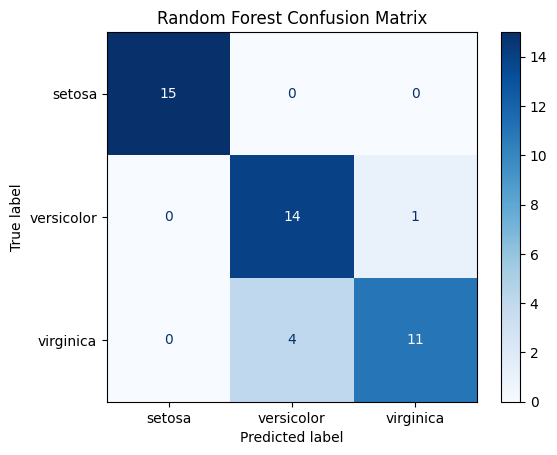

In [11]:
# predictions
y_pred = rf_model.predict(X_test)

# overall classification accuracy
accuracy = accuracy_score(y_test, y_pred)
print('++'*60)
print("The overall accuracy of the Random Forest Classifier is (Test Set):\n", accuracy)
print('++'*60)

# classification report
cr = classification_report(y_test, y_pred, target_names=iris.target_names)
print('++'*60)
print("Random Forest Classification Report (Test Set):\n", cr)

# plot confusion matrix only
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test,
    display_labels=iris.target_names,
    cmap="Blues"
)
disp.ax_.set_title("Random Forest Confusion Matrix")
plt.show()


In [17]:
# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize model
model = RandomForestClassifier(random_state=42)

# Track scores
accuracy_scores = []

# Cross-validation loop
for train_index, val_index in kf.split(X):
    # Split data
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    
# Train model
model.fit(X_train, y_train)
    
# Predict and evaluate
y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)
accuracy_scores.append(acc)
print(f'Fold accuracy: {acc:.4f}')

# Final result
print(f'\nAverage Accuracy: {np.mean(accuracy_scores):.4f}')


Fold accuracy: 0.9667

Average Accuracy: 0.9667
